In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import KFold
from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn import linear_model
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import make_scorer, r2_score
from sklearn.metrics import classification_report
from sklearn.metrics import mean_absolute_error
import statistics
from statistics import mean


In [ ]:
df = pd.read_csv('clean_kaggle_data_2022.csv', encoding = 'latin1' ) #import data
df #original dataframe


,Duration (in seconds),Q2,Q3,Q4,Q5,Q6_1,Q6_2,Q6_3,Q6_4,Q6_5,...,Q44_5,Q44_6,Q44_7,Q44_8,Q44_9,Q44_10,Q44_11,Q44_12,Q29_Encoded,Q29_buckets
0,Duration (in seconds),What is your age (# years)?,What is your gender? - Selected Choice,In which country do you currently reside?,"Are you currently a student? (high school, uni...",On which platforms have you begun or completed...,On which platforms have you begun or completed...,On which platforms have you begun or completed...,On which platforms have you begun or completed...,On which platforms have you begun or completed...,...,Who/what are your favorite media sources that ...,Who/what are your favorite media sources that ...,Who/what are your favorite media sources that ...,Who/what are your favorite media sources that ...,Who/what are your favorite media sources that ...,Who/what are your favorite media sources that ...,Who/what are your favorite media sources that ...,Who/what are your favorite media sources that ...,NaN,NaN
1,851,55-59,Man,France,No,Coursera,NaN,Kaggle Learn Courses,NaN,NaN,...,"Course Forums (forums.fast.ai, Coursera forums...",NaN,NaN,"Blogs (Towards Data Science, Analytics Vidhya,...",NaN,NaN,NaN,NaN,2.0,"20,000-29,999"
2,501,30-34,Man,Germany,No,Coursera,edX,NaN,NaN,NaN,...,NaN,"YouTube (Kaggle YouTube, Cloud AI Adventures, ...",NaN,"Blogs (Towards Data Science, Analytics Vidhya,...",NaN,NaN,NaN,NaN,10.0,"100,000-124,999"
3,787,70+,Man,Australia,No,Coursera,NaN,Kaggle Learn Courses,NaN,NaN,...,NaN,NaN,"Podcasts (Chai Time Data Science, OEEReilly...",NaN,NaN,NaN,NaN,NaN,10.0,"100,000-124,999"
4,1132,40-44,Man,United States of America,No,Coursera,NaN,Kaggle Learn Courses,NaN,Fast.ai,...,NaN,NaN,"Podcasts (Chai Time Data Science, OEEReilly...","Blogs (Towards Data Science, Analytics Vidhya,...",NaN,NaN,NaN,NaN,13.0,"200,000-299,999"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8132,540,40-44,Man,United States of America,No,NaN,NaN,Kaggle Learn Courses,DataCamp,NaN,...,NaN,"YouTube (Kaggle YouTube, Cloud AI Adventures, ...",NaN,"Blogs (Towards Data Science, Analytics Vidhya,...",NaN,NaN,NaN,NaN,10.0,"100,000-124,999"
8133,603,35-39,Man,India,No,NaN,NaN,NaN,NaN,NaN,...,NaN,"YouTube (Kaggle YouTube, Cloud AI Adventures, ...",NaN,NaN,NaN,NaN,NaN,NaN,0.0,"0-9,999"
8134,557,40-44,Man,India,No,NaN,NaN,NaN,DataCamp,NaN,...,NaN,"YouTube (Kaggle YouTube, Cloud AI Adventures, ...",NaN,NaN,NaN,NaN,NaN,NaN,0.0,"0-9,999"
8135,860,25-29,Man,Turkey,No,NaN,NaN,NaN,DataCamp,NaN,...,NaN,"YouTube (Kaggle YouTube, Cloud AI Adventures, ...",NaN,NaN,NaN,NaN,NaN,NaN,2.0,"20,000-29,999"


In [ ]:
check_null = df.isnull().sum(axis=0) #See how many missing values are in each column
print(check_null)

print("To see which columns contain NAN:")
print(check_null.loc[check_null > 0]) #There are 285 out of 298 columns in df containing missing values.

Duration (in seconds)       0
Q2                          0
Q3                          0
Q4                          0
Q5                          0
                         ... 
Q44_10                   7370
Q44_11                   7731
Q44_12                   7820
Q29_Encoded                 1
Q29_buckets                 1
Length: 298, dtype: int64
To see which columns contain NAN:
Q6_1           4374
Q6_2           7018
Q6_3           5756
Q6_4           6679
Q6_5           7663
               ... 
Q44_10         7370
Q44_11         7731
Q44_12         7820
Q29_Encoded       1
Q29_buckets       1
Length: 285, dtype: int64


#Part 1: Data Cleaning

1.Remove useless columns
- 1.1) drop multiple choices columns with "Others" as they provide no information
- 1.2) remove features: 'Duration (in seconds)','Q29',and 'Q29_buckets' because Q29_Encoded already contains necessary info for Q29. The response time is not relevant to the target variable "Q29_Encoded".

In [ ]:
Other_columns = ['Q6_12','Q7_7','Q12_15','Q13_14','Q14_16','Q15_15','Q17_15','Q18_14','Q19_8','Q20_6',
                 'Q21_10','Q28_8','Q31_12','Q33_5','Q34_8','Q35_16','Q36_15','Q37_13','Q38_8','Q39_12',
                 'Q40_15','Q41_9','Q42_9','Q44_12']

df = df.drop(Other_columns, axis=1)
#len(Other_columns)

In [ ]:
df.shape #after removing columns of OTHERS，the new df has 274 columns (24 columns are removed)
remove_features = ['Duration (in seconds)', 'Q32','Q29','Q29_buckets']
df.drop(labels = remove_features, axis=1, inplace=True)
df.shape #270 columns left

(8137, 270)

In [ ]:
# Select categorical columns
categorical_columns = ['Q2','Q3','Q4','Q5','Q8','Q9','Q10_1','Q10_2','Q10_3','Q11','Q16','Q22','Q23','Q24','Q25','Q26','Q27','Q30','Q43']

columns = list(df.columns)

multiple_choice_questions = []
for i in columns:
  if i not in categorical_columns:
    multiple_choice_questions.append(i)

# Count missing values
df[categorical_columns].isna().sum()

Q2          0
Q3          0
Q4          0
Q5          0
Q8          0
Q9       2941
Q10_1    7452
Q10_2    6845
Q10_3    7101
Q11         0
Q16       684
Q22      6522
Q23         0
Q24         0
Q25         0
Q26         0
Q27         0
Q30        50
Q43      3723
dtype: int64

It can be seen that there are quite some missing values present in Q9, Q10,Q16, Q22, Q30 and Q43.

2.Now, I would like to deal with missing Values in each of the categorical variables. After that, I will encode the categorical variables.


In [ ]:
Q10_parts = ['Q10_1','Q10_2','Q10_3'] #since there are too many NAN in Q10, so drop these 3 columns
categorical_columns = ['Q2','Q3','Q4','Q5','Q8','Q9','Q11','Q16','Q23','Q24','Q25','Q26','Q27','Q30','Q43']

df.drop(Q10_parts,axis=1,inplace=True)
df.shape

(8137, 267)

In [ ]:
print('Q9: Have you ever published any academic research (papers, preprints, conference proceedings, etc)?')
df.loc[df['Q9'].isnull(), 'Q9'] = 'Unknown' #fill the NaN values in the 'Q9' column with 'Unknown'
df['Q9'].value_counts()

Q9: Have you ever published any academic research (papers, preprints, conference proceedings, etc)?


Unknown                                                                                            2941
Yes                                                                                                2672
No                                                                                                 2523
Have you ever published any academic research (papers, preprints, conference proceedings, etc)?       1
Name: Q9, dtype: int64

In [ ]:
print('Q16:For how many years have you used machine learning methods')
df.loc[df['Q16'].isnull(), 'Q16'] = 'I do not use machine learning methods' #I assume that for those people who did not respond to this question have no experience with using machine learning methods.
df['Q16'].value_counts()


Q16:For how many years have you used machine learning methods


I do not use machine learning methods                         1791
Under 1 year                                                  1724
1-2 years                                                     1266
2-3 years                                                      955
5-10 years                                                     808
4-5 years                                                      635
3-4 years                                                      591
10-20 years                                                    366
For how many years have you used machine learning methods?       1
Name: Q16, dtype: int64

In [ ]:
df['Q5'].value_counts()

No                                                                     8136
Are you currently a student? (high school, university, or graduate)       1
Name: Q5, dtype: int64

In [ ]:
df.drop(labels='Q5', axis=1, inplace =True) #as all respondents are not student -> drop
df.shape

(8137, 266)

In [ ]:
df = df.drop(df[df['Q29_Encoded'].isnull()==True].index) #drop the missing value in Q29_Encoded

In [ ]:
print("Q22:Which of the following ML model hubs/repositories do you use most often?")
df['Q22'].value_counts()

Q22:Which of the following ML model hubs/repositories do you use most often?


 Kaggle datasets                              621
  TensorFlow Hub                              350
 Huggingface Models                           286
 PyTorch Hub                                  186
 Timm                                          76
Other storage services (i.e. google drive)     37
 NVIDIA NGC models                             32
 ONNX models                                   20
 Jumpstart                                      6
Name: Q22, dtype: int64

In [ ]:
print("Q30: Approximately how much money have you spent on machine learning and/or cloud computing services at home or at work in the past 5 years (approximate $USD)")
df['Q30'].value_counts()

Q30: Approximately how much money have you spent on machine learning and/or cloud computing services at home or at work in the past 5 years (approximate $USD)


$0 ($USD)                  2653
$100-$999                  1993
$1000-$9,999               1412
$1-$99                     1401
$10,000-$99,999             453
$100,000 or more ($USD)     174
Name: Q30, dtype: int64

In [ ]:
print("Q43:Approximately how many times have you used a TPU (tensor processing unit)?")
df['Q43'].value_counts()

Q43:Approximately how many times have you used a TPU (tensor processing unit)?


Never                 2429
2-5 times              922
Once                   586
6-25 times             255
More than 25 times     221
Name: Q43, dtype: int64

In [ ]:
df['Q22'].fillna(df['Q22'].mode()[0],inplace=True) #replace null with mode
df['Q30'].fillna(df['Q30'].mode()[0],inplace=True) #replace null with mode
df.loc[df['Q43'].isnull(), 'Q43'] = 'Never' # I replace null value with never，because people who didnot respond may be due to not understanding what TPU is， hence no experience with TPU.


In [ ]:
categorical_columns = ['Q2','Q3','Q4','Q8','Q9','Q11','Q16','Q22','Q23','Q24','Q25','Q26','Q27','Q30','Q43']

df[categorical_columns].isna().sum()

Q2     0
Q3     0
Q4     0
Q8     0
Q9     0
Q11    0
Q16    0
Q22    0
Q23    0
Q24    0
Q25    0
Q26    0
Q27    0
Q30    0
Q43    0
dtype: int64

3.Now, encode the categorical variables:
- encode nominal variables with pandas.getdummies()
- encode ordinal variables with LabelEncoder()

In [ ]:
#categorical_columns = ['Q2','Q3','Q4','Q8','Q9','Q11','Q16','Q22','Q23','Q24','Q25','Q26','Q27','Q30','Q43']

nominal_features = ['Q3','Q4','Q9','Q22','Q23','Q24']
ordinal_features = [x for x in categorical_columns if x not in nominal_features]
print("norminal features are:",nominal_features)
print("ordinal features are:",ordinal_features)


norminal features are: ['Q3', 'Q4', 'Q9', 'Q22', 'Q23', 'Q24']
ordinal features are: ['Q2', 'Q8', 'Q11', 'Q16', 'Q25', 'Q26', 'Q27', 'Q30', 'Q43']


In [ ]:
#for nominal features, encode with pd.get_dummies()
df_Q3 = pd.get_dummies(df['Q3'], prefix='Q3')
df_Q4 = pd.get_dummies(df['Q4'], prefix='Q4')
df_Q9 = pd.get_dummies(df['Q9'], prefix='Q9')
df_Q22 = pd.get_dummies(df['Q22'], prefix='Q22')
df_Q23 = pd.get_dummies(df['Q23'], prefix='Q23')
df_Q24 = pd.get_dummies(df['Q24'], prefix='Q24')

# use pandas concatenate to concatenate df with dummies
df = pd.concat([df, df_Q3, df_Q4, df_Q9, df_Q22, df_Q23, df_Q24], axis=1)
df = df.drop(['Q3','Q4','Q9','Q22','Q23','Q24'],axis=1)


In [ ]:
#for ordinal features, labelEncoder() is used to convert it into numerical data.
for i in ordinal_features:
    df[i] = LabelEncoder().fit_transform(df[i])
df.head()

,Q2,Q6_1,Q6_2,Q6_3,Q6_4,Q6_5,Q6_6,Q6_7,Q6_8,Q6_9,...,Q24_Government/Public Service,Q24_Insurance/Risk Assessment,Q24_Manufacturing/Fabrication,Q24_Marketing/CRM,Q24_Medical/Pharmaceutical,Q24_Non-profit/Service,Q24_Online Service/Internet-based Services,Q24_Other,Q24_Retail/Sales,Q24_Shipping/Transportation
1,8,Coursera,NaN,Kaggle Learn Courses,NaN,NaN,NaN,Udemy,NaN,NaN,...,0,0,0,0,0,0,1,0,0,0
2,3,Coursera,edX,NaN,NaN,NaN,Udacity,Udemy,NaN,NaN,...,0,1,0,0,0,0,0,0,0,0
3,10,Coursera,NaN,Kaggle Learn Courses,NaN,NaN,NaN,NaN,NaN,NaN,...,1,0,0,0,0,0,0,0,0,0
4,5,Coursera,NaN,Kaggle Learn Courses,NaN,Fast.ai,Udacity,Udemy,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
5,5,Coursera,NaN,NaN,NaN,NaN,Udacity,Udemy,NaN,"Cloud-certification programs (direct from AWS,...",...,0,0,0,0,0,0,0,0,0,0


4.Deal with mutiple-choices questions:
- fill nulls with 0 and 1 otherwise

In [ ]:
#Dealing with multi_choices columns
multiple_choice_questions.remove('Q29_Encoded') #Q29_Encoded is the target, not features
df[multiple_choice_questions]

print(df[multiple_choice_questions].isna().sum())

Q6_1      4374
Q6_2      7018
Q6_3      5756
Q6_4      6679
Q6_5      7663
          ... 
Q44_7     7117
Q44_8     4513
Q44_9     6296
Q44_10    7370
Q44_11    7731
Length: 250, dtype: int64


In [ ]:
for i in multiple_choice_questions:
    df.loc[df[i].notnull(), i] = 1 #if it is not missing, then replace with 1
    df[i].fillna(0,inplace=True) #replace null with 0

In [ ]:
df

,Q2,Q6_1,Q6_2,Q6_3,Q6_4,Q6_5,Q6_6,Q6_7,Q6_8,Q6_9,...,Q24_Government/Public Service,Q24_Insurance/Risk Assessment,Q24_Manufacturing/Fabrication,Q24_Marketing/CRM,Q24_Medical/Pharmaceutical,Q24_Non-profit/Service,Q24_Online Service/Internet-based Services,Q24_Other,Q24_Retail/Sales,Q24_Shipping/Transportation
1,8,1,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
2,3,1,1,0,0,0,1,1,0,0,...,0,1,0,0,0,0,0,0,0,0
3,10,1,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,5,1,0,1,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,5,1,0,0,0,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8132,5,0,0,1,1,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
8133,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8134,5,0,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
8135,2,0,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


#Part2：Exploratory data analysis and feature selection

In [ ]:
df['Q29_Encoded']

1        2.0
2       10.0
3       10.0
4       13.0
5       13.0
        ... 
8132    10.0
8133     0.0
8134     0.0
8135     2.0
8136     1.0
Name: Q29_Encoded, Length: 8136, dtype: float64

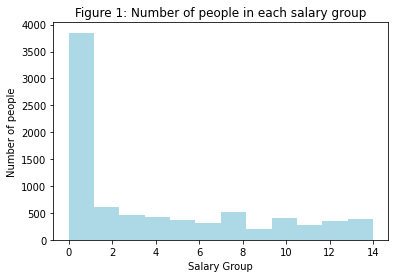

In [ ]:
#visualize the target group
plt.hist(df['Q29_Encoded'].values,color="lightblue", bins=12)
plt.xlabel('Salary Group')
plt.ylabel('Number of people')
plt.title('Figure 1: Number of people in each salary group')
plt.show()

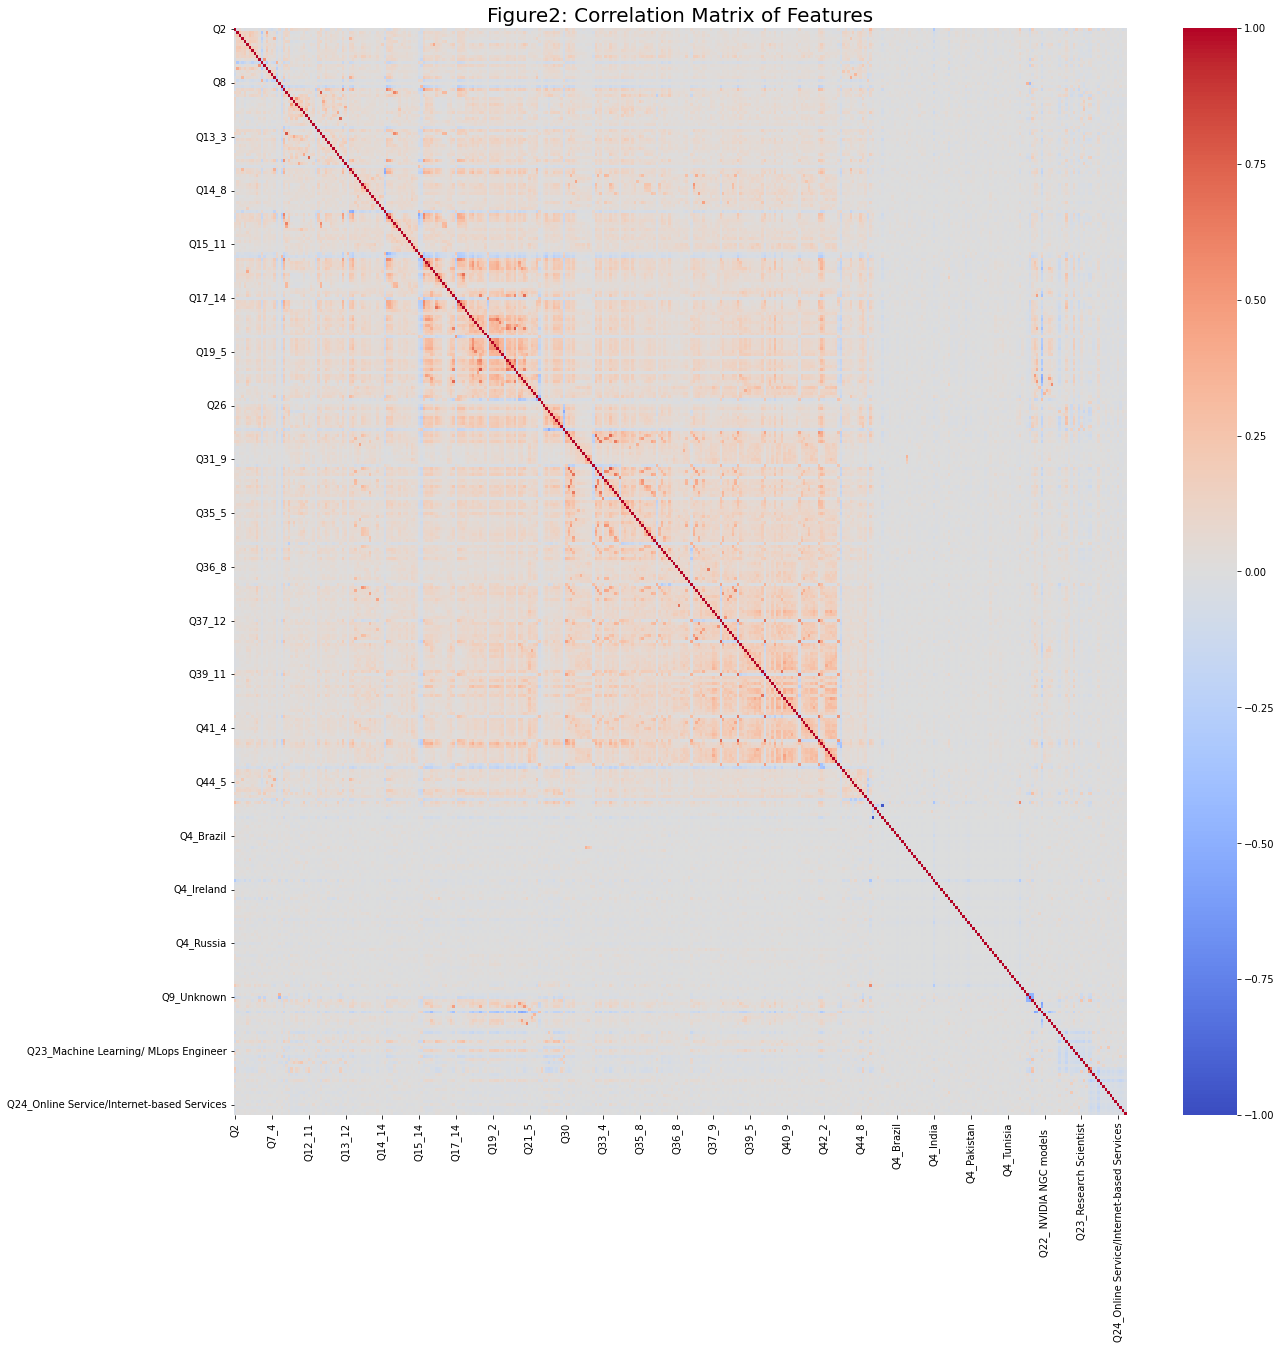

In [ ]:
#correlation plot
ax = sns.heatmap(df.corr(),annot=False,fmt='.1g',vmin=-1, vmax=1, center= 0,cmap='coolwarm')
plt.title('Figure2: Correlation Matrix of Features',fontsize =20)
fig = plt.gcf()
fig.set_size_inches(20,20)
plt.show()

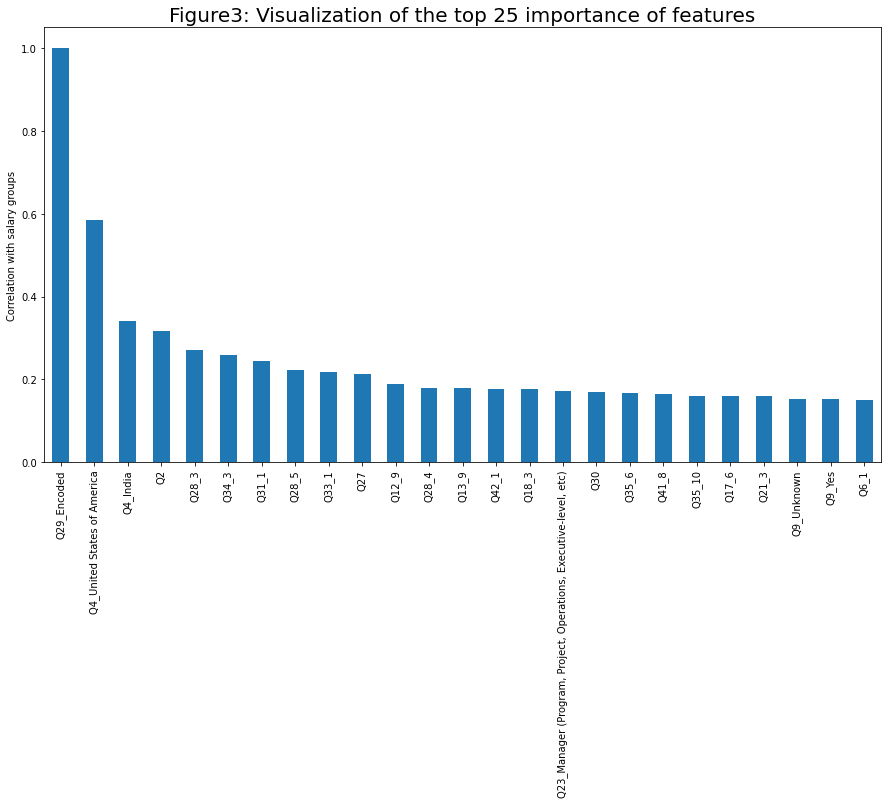

In [ ]:
correlation = df.corr().Q29_Encoded.apply(lambda x:abs(x)).sort_values(ascending=False) #determine how strongly each feature correlates with the target
ax = (correlation.iloc[0:25].plot(kind="bar",figsize=(15,8), title="Importance of features")) #plots top 25 features for visualization, will get messy if all are plotted.
ax.set_ylabel('Correlation with salary groups')
plt.title('Figure3: Visualization of the top 25 importance of features',fontsize =20)
plt.show()

In [ ]:
print("Top 25 Feature's correlation with the target variable Q29_Encoded")
print(correlation.iloc[0:25])

Top 25 Feature's correlation with the target variable Q29_Encoded
Q29_Encoded                                                         1.000000
Q4_United States of America                                         0.584453
Q4_India                                                            0.339819
Q2                                                                  0.315812
Q28_3                                                               0.270721
Q34_3                                                               0.257707
Q31_1                                                               0.243671
Q28_5                                                               0.223667
Q33_1                                                               0.217620
Q27                                                                 0.213171
Q12_9                                                               0.187849
Q28_4                                                               0.179178
Q13_9     

Feature Selection:
- It improves the accuracy of a model if the right subset is chosen.
- It reduces overfitting.
- It enables a faster training time.
- It reduces the complexity of a model and makes it easier to interpret.



In [ ]:
X_part2 = df.drop(['Q29_Encoded'],axis=1) #features dataframe
y_part2 = pd.DataFrame(df['Q29_Encoded']) #target dataframe

In [ ]:
# Split Data into training and testing set
X_train_part2, X_test_part2, y_train_part2, y_test_part2 = train_test_split(X_part2, y_part2, test_size=0.3, random_state=20)

# Normalize data because features with different scales may lead to bias, so we need all features to be on the same scale.
scaler = StandardScaler()
X_train_part2_scaled = scaler.fit(X_train_part2).transform(X_train_part2)
X_test_part2_scaled = scaler.fit(X_train_part2).transform(X_test_part2)

In [ ]:
# Use Lasso and find the best parameter value by using Gridsearch
reg_gridsearch = linear_model.Lasso(random_state=20)
# Parameter set to test
parameter_set = {'alpha':[0.1,10,1]}
# Gridsearch
acc_scorer_lm = make_scorer(r2_score)
grid = GridSearchCV(reg_gridsearch, parameter_set, scoring = acc_scorer_lm)
grid = grid.fit(X_train_part2_scaled, y_train_part2)

# Select the one with best parameter combination
reg_best_grid = grid.best_estimator_

# Print the optimal parameters
print(reg_best_grid)

Lasso(alpha=0.1, random_state=20)


In [ ]:
print('Best grid score is:',reg_best_grid.score(X_train_part2_scaled,y_train_part2))
# Feature importance
feature_importance = reg_best_grid.coef_
print("feature importance are",feature_importance) # there are a lot of zeros observed in the feature importance

Best grid score is: 0.5788560506382082
feature importance are [ 5.73441630e-01  1.87782238e-02  0.00000000e+00 -0.00000000e+00
  0.00000000e+00  1.11040731e-01  0.00000000e+00 -1.69827235e-02
  0.00000000e+00 -0.00000000e+00  6.06104369e-03  0.00000000e+00
  2.70451169e-02 -0.00000000e+00  0.00000000e+00 -6.69303199e-02
 -0.00000000e+00  0.00000000e+00 -0.00000000e+00 -8.62018056e-04
  0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00  0.00000000e+00
  5.68948485e-02 -4.57356307e-02 -0.00000000e+00  0.00000000e+00
  0.00000000e+00 -0.00000000e+00  0.00000000e+00  0.00000000e+00
 -0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
  0.00000000e+00  0.00000000e+00  6.44487325e-02 -0.00000000e+00
 -0.00000000e+00  0.00000000e+00 -0.00000000e+00 -0.00000000e+00
 -5.34624248e-02  0.00000000e+00 -0.00000000e+00 -0.00000000e+00
  0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
  0.00000000e+00 -2.37174020

In [ ]:
X_selected = X_part2 #make a copy so that we don't modify the original features dataframe
X_train_selected = X_train_part2
X_test_selected = X_test_part2

selected_feature_importance = []
selected_features = []
selected_features_index = []

removed_features = []
removed_feature_index = []

selected_features = []
for i in range(len(feature_importance)):
  if abs(feature_importance[i]) > 0:
    selected_features.append(X_part2.columns[i])
    selected_feature_importance.append(feature_importance[i])
    selected_features_index.append(i)
  else: #when we observe a feature importance of zero --> drop the feature
    removed_features.append(X_part2.columns[i])
    removed_feature_index.append(i)
    X_selected = X_selected.drop([X_part2.columns[i]], axis = 1) #remove feature from the original features dataframe
    X_train_selected = X_train_selected.drop([X_part2.columns[i]], axis = 1) #remove feature from X_train
    X_test_selected = X_test_selected.drop([X_part2.columns[i]], axis = 1) #remove feature from X_test

In [ ]:
X_selected.shape

(8136, 87)

In [ ]:
X_selected.columns

Index(['Q2', 'Q6_1', 'Q6_5', 'Q6_7', 'Q6_10', 'Q7_1', 'Q7_4', 'Q11', 'Q12_9',
       'Q12_10', 'Q13_9', 'Q14_2', 'Q14_11', 'Q14_12', 'Q15_6', 'Q15_9',
       'Q17_7', 'Q17_13', 'Q18_1', 'Q18_3', 'Q18_11', 'Q19_7', 'Q21_3',
       'Q21_8', 'Q21_9', 'Q26', 'Q27', 'Q28_1', 'Q28_3', 'Q28_4', 'Q28_5',
       'Q30', 'Q31_1', 'Q31_2', 'Q33_1', 'Q34_1', 'Q34_3', 'Q35_1', 'Q35_6',
       'Q35_10', 'Q36_4', 'Q36_8', 'Q36_9', 'Q36_13', 'Q39_3', 'Q40_7',
       'Q44_1', 'Q44_5', 'Q44_6', 'Q44_8', 'Q3_Woman', 'Q4_Argentina',
       'Q4_Australia', 'Q4_Bangladesh', 'Q4_Belgium', 'Q4_Canada',
       'Q4_Colombia', 'Q4_Egypt', 'Q4_Ethiopia', 'Q4_France', 'Q4_Germany',
       'Q4_Hong Kong (S.A.R.)', 'Q4_India', 'Q4_Indonesia', 'Q4_Ireland',
       'Q4_Israel', 'Q4_Netherlands', 'Q4_Nigeria', 'Q4_Pakistan', 'Q4_Peru',
       'Q4_Philippines', 'Q4_Saudi Arabia', 'Q4_Singapore', 'Q4_South Korea',
       'Q4_Spain', 'Q4_United Arab Emirates',
       'Q4_United Kingdom of Great Britain and Northern Ireland

#Visualize the feature importance based on the selected features.

In [ ]:
new_df = pd.concat([X_selected, y_part2], axis = 1) #join the selected features dataframe and the target dataframe together so a correlation plot can be plotted
new_df.head()

,Q2,Q6_1,Q6_5,Q6_7,Q6_10,Q7_1,Q7_4,Q11,Q12_9,Q12_10,...,Q4_Viet Nam,Q9_Unknown,Q9_Yes,"Q23_Data Analyst (Business, Marketing, Financial, Quantitative, etc)","Q23_Manager (Program, Project, Operations, Executive-level, etc)",Q23_Software Engineer,Q23_Statistician,Q24_Academics/Education,Q24_Accounting/Finance,Q29_Encoded
1,8,1,0,1,0,0,0,1,1,0,...,0,1,0,0,0,0,0,0,0,2.0
2,3,1,0,1,0,1,1,1,0,1,...,0,1,0,0,0,1,0,0,0,10.0
3,10,1,0,0,0,0,0,2,0,0,...,0,0,1,0,0,0,0,0,0,10.0
4,5,1,1,1,0,1,0,1,0,0,...,0,0,1,0,0,0,0,0,0,13.0
5,5,1,0,1,0,1,0,1,1,0,...,0,0,1,0,0,0,0,0,0,13.0


In [ ]:
new_corr = new_df.corr()
new_corr.style.background_gradient(cmap='coolwarm').set_precision(3)

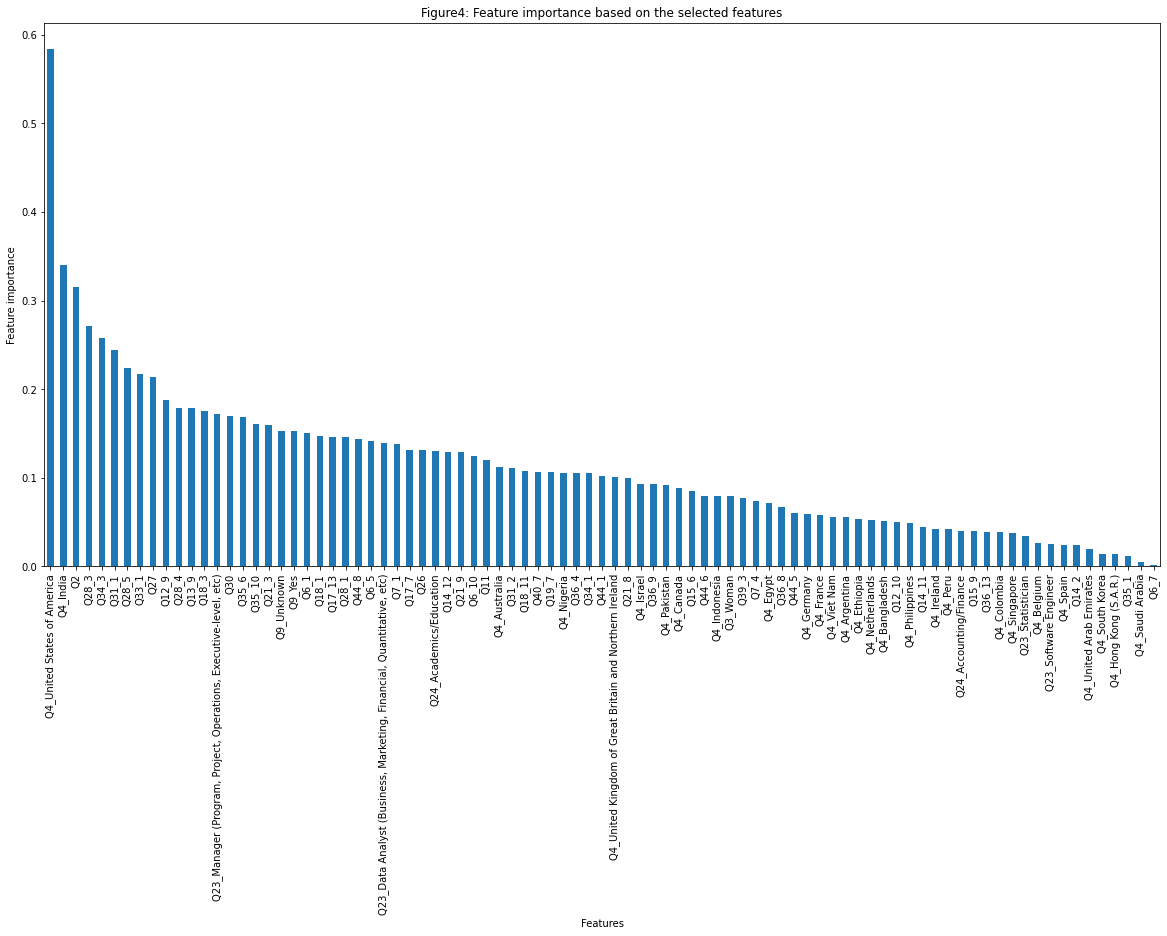

In [ ]:
target_corr = new_corr.shape[0]-1
correlation = abs(new_corr.iloc[target_corr,0:-1]).sort_values(ascending=False)

plt.figure(figsize=(20,10))
correlation.plot(kind='bar')
plt.title('Figure4: Feature importance based on the selected features')
plt.xlabel('Features')
plt.ylabel('Feature importance')
plt.show()

#PART3: Model implementation
- Implement an ordinal logistic regression model

In [ ]:
y = pd.DataFrame(df['Q29_Encoded']) #target dataframe
X_selected

X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(X_selected, y,  test_size=0.3, random_state=42)


In [ ]:
scaler = StandardScaler()
X_train_selected_scaled = scaler.fit_transform(X_train_selected)
X_test_selected_scaled = scaler.fit(X_train_selected).transform(X_test_selected)

y_train_selected_scaled = scaler.fit(y_train_selected).transform(y_train_selected)
X_test_selected_scaled = scaler.fit(y_train_selected).transform(y_test_selected)

In [ ]:
df['Q29_Encoded'].unique()

array([ 2., 10., 13., 12.,  9.,  3.,  0.,  5., 11.,  1.,  8., 14.,  7.,
        6.,  4.])

In [ ]:
def ordinal_logistic_regression_model(X_train, y_train, X_test, model): #since there are 15 classes in the target, hence we need 14 models.
    y = []
    p0 = 0 #initialize
    prob_score = []
    for i in range(0,14): #class 0-13
      y = []
      for j in y_train:
        if j <= i:
          y.append(0)
        else:
          y.append(1)
      model.fit(X_train, y)
      p_predit = model.predict_proba(X_test)[:,0]
      p = p_predit - p0
      prob_score.append(p)
      p0 = p_predit
    y_2 = []
    for j in y_train:
      if j < 14:
        y_2.append(0)
      else:
        y_2.append(1)
    model.fit(X_train, y_2)
    # probability for the last class:
    p_pred_last = model.predict_proba(X_test)[:,1]
    prob_score.append(p_pred_last)
    best_prob_score = np.argmax(prob_score, axis = 0) #take the argmax from the prob scores to determine the final classification result

    return best_prob_score


In [ ]:
#Implement ordinal logistic regression algorithm on the training data using 10-fold crossvalidation.
model = LogisticRegression()
scaler = StandardScaler()
kfold = KFold(n_splits=10) #apply 10-folds cross validation
kfold.get_n_splits(X_train_selected)
accuracy = np.zeros(10)
np_idx = 0 #initialize

for train_idx, val_idx in kfold.split(X_train_selected): #training data is further divided to create validation set
    X_train, X_val = X_train_selected.values[train_idx], X_train_selected.values[val_idx]
    y_train, y_val = y_train_selected.values[train_idx], y_train_selected.values[val_idx]

    X_train = scaler.fit_transform(X_train) #requires standardization on training and testing set seperately
    X_val = scaler.transform(X_val)

    best_prob_score_model = ordinal_logistic_regression_model(X_train, y_train, X_val, model)

    ACC = accuracy_score(best_prob_score_model, y_val) * 100
    accuracy[np_idx] = ACC

    np_idx += 1

    print ("Fold {}: Accuracy: {}%".format(np_idx, round(ACC,3))) #accuracy for each fold

print("It has an average score of:",round(np.mean(accuracy),3),"% and variance equals to", round(np.std(accuracy),3),"%")

Fold 1: Accuracy: 39.298%
Fold 2: Accuracy: 39.825%
Fold 3: Accuracy: 39.474%
Fold 4: Accuracy: 37.895%
Fold 5: Accuracy: 41.93%
Fold 6: Accuracy: 39.719%
Fold 7: Accuracy: 36.38%
Fold 8: Accuracy: 37.786%
Fold 9: Accuracy: 40.422%
Fold 10: Accuracy: 44.464%
It has an average score of: 39.719 % and variance equals to 2.153 %


In [ ]:
#Change the value of hyperparamter C to visualize bias-variance tradeoff
mean_bias = []
mean_variance = []

for c in [0.0005,0.001,0.01,0.05,0.1,1,10,100]:
    np_idx = 0 #initialize
    bias_c = np.zeros(10)
    variance_c = np.zeros(10)
    model = LogisticRegression(C=c)
    bias_list = []
    variance_list = []


    #perform 10 fold cross validation:

    for train_idx, val_idx in kfold.split(X_train_selected): #split the training set into new train and validation set
      X_train, X_val = X_train_selected.values[train_idx], X_train_selected.values[val_idx]
      y_train, y_val = y_train_selected.values[train_idx], y_train_selected.values[val_idx]
      X_train = scaler.fit_transform(X_train) #requires standardization on training and validation set
      X_val = scaler.transform(X_val)

      #call the function to predict the probabilities for 15 classes
      best_prob_score_model = ordinal_logistic_regression_model(X_train, y_train, X_val, model)
      bias_c[np_idx] = np.power(np.mean(best_prob_score_model - y_val),2)
      variance_c = np.mean(np.power(np.mean(best_prob_score_model) - best_prob_score_model,2))

      bias_list.append(bias_c.mean())
      variance_list.append(variance_c.mean())

      np_idx += 1

    mean_bias.append(mean(bias_list))
    mean_variance.append(mean(variance_list))

In [ ]:
C_list = [0.0005,0.001,0.01,0.05,0.1,1,10,100]
bias_variance_df = pd.DataFrame({'C' : C_list, 'Bias' : mean_bias,'Variance' : mean_variance})
bias_variance_df

,C,Bias,Variance
0,0.0005,5.206229,7.119007
1,0.0010,3.470202,11.787086
2,0.0100,0.819927,18.524942
3,0.0500,0.519118,19.370505
4,0.1000,0.480103,19.578001
5,1.0000,0.426571,19.855330
6,10.0000,0.419858,19.888914
7,100.0000,0.420377,19.888964


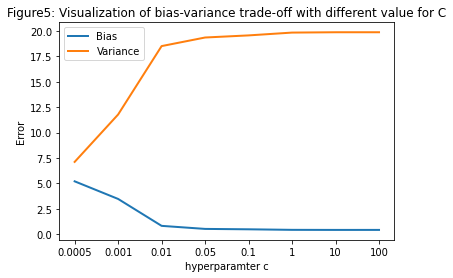

In [ ]:
#Visualize bias-variance tradeoff
plt.plot(mean_bias, label="Bias",linewidth = 2)
plt.plot(mean_variance, label="Variance", linewidth = 2)
plt.legend()
plt.title("Figure5: Visualization of bias-variance trade-off with different value for C")
plt.xlabel('hyperparamter c')
plt.ylabel('Error')
plt.xticks(range(len(C_list)), C_list)
plt.show()

#Part 4: Model Tuning

In [ ]:
model = LogisticRegression()
scaler = StandardScaler()
kfold = KFold(n_splits=10) #apply 10-folds cross validation
kfold.get_n_splits(X_train)

best_model = model
best_params = {}
best_accuracy = 0
best_f1_score = 0
best_std = 0

best_std_accuracy = 0
best_std_f1_score = 0

#Optimize model using GridSearch：

for c in [0.0005,0.001,0.01,0.05,0.1,1,10,100]:
  for solver in ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']:

    model = LogisticRegression(C=c, solver=solver)
    accuracy = np.zeros(10)
    F1_scores = np.zeros(10)

    np_idx = 0

    for train_idx, val_idx in kfold.split(X_train_selected):
      #split the training set into new train and validation set
      X_train, X_val = X_train_selected.values[train_idx], X_train_selected.values[val_idx]
      y_train, y_val = y_train_selected.values[train_idx], y_train_selected.values[val_idx]
      X_train = scaler.fit_transform(X_train) #requires standardization on training and validation set
      X_val = scaler.transform(X_val)

      best_prob_score_model = ordinal_logistic_regression_model(X_train, y_train, X_val, model)

      #Performance Measures:
      ACC = accuracy_score(best_prob_score_model, y_val)
      accuracy[np_idx] = ACC*100
      F1 = f1_score(best_prob_score_model, y_val, average = 'macro')
      F1_scores[np_idx] = F1*100

      np_idx += 1

      if np.mean(F1_scores) > best_f1_score:
        best_model = model
        best_params = {'C':c, 'solver':solver}
        best_accuracy = np.mean(accuracy)
        best_f1_score = np.mean(F1_scores)

        best_accuracy_std = np.std(accuracy)
        best_f1_score_std = np.std(F1_scores)



In [ ]:
print("After model tuning:")
print ("\nThe optimal log model uses C={}, and a {} solver, and has a cross validation score of {}% with a standard deviation of {}%".format(best_params['C'],best_params['solver'],round(best_accuracy,3),round(best_accuracy_std,3)))

print ("Best F1 score: {}%({}%)".format(round(best_f1_score,3),round(best_std_f1_score,3)))



After model tuning:

The optimal log model uses C=1, and a sag solver, and has a cross validation score of 39.719% with a standard deviation of 2.153%
Best F1 score: 14.198%(0%)


In [ ]:
#Fit the model using the optimal paramters：
optimal_model = LogisticRegression(C = 1, solver = 'sag')
optimal_model.fit(X_train_selected_scaled, y_train_selected)

LogisticRegression(C=1, solver='sag')

In [ ]:
importance = abs(optimal_model.coef_[0])


In [ ]:
part_4_importance=pd.DataFrame({'Features' : X_train_selected.columns, 'importance' : importance})
part_4_importance_sorted=part_4_importance.sort_values(by=['importance'],ascending=False)

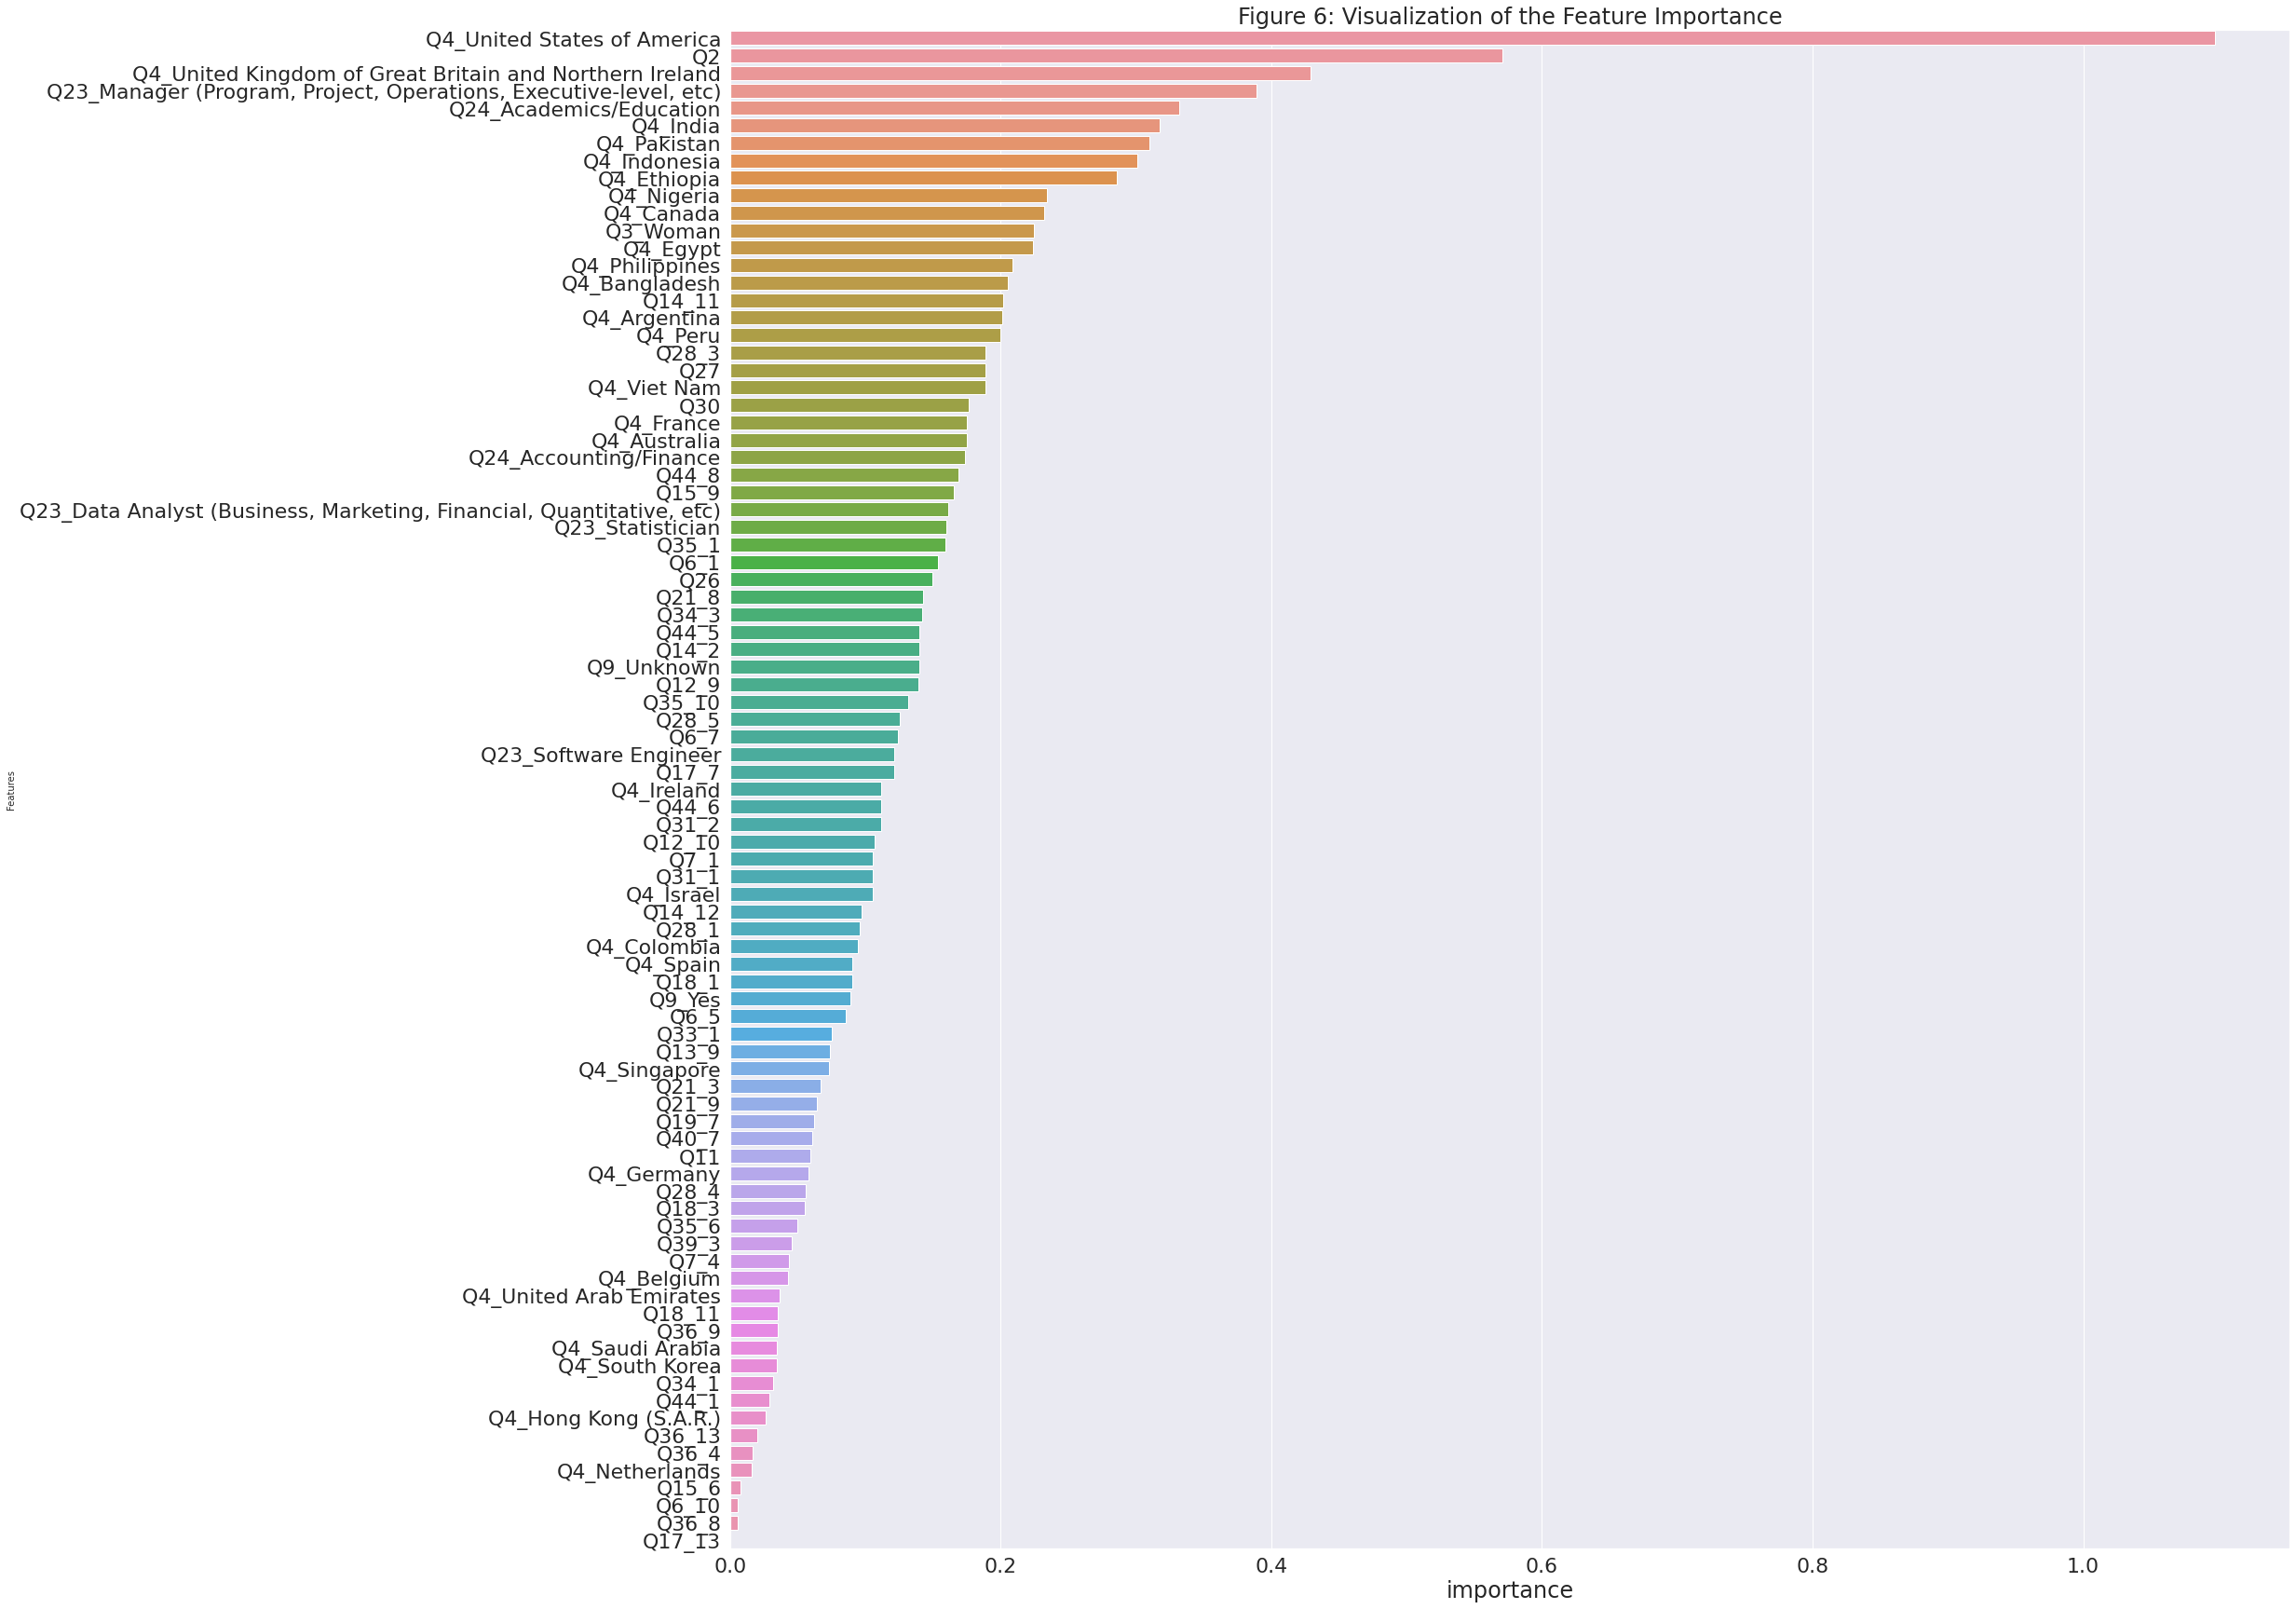

In [ ]:
fig,ax=plt.subplots(figsize=(30,30))
sns.barplot(ax=ax, data=part_4_importance_sorted, x='importance',y='Features')
plt.ylabel('Features',fontsize=10)
plt.title('Figure 6: Visualization of the Feature Importance')
plt.show()

#Part5：Testing and Discussion

In [ ]:
# scaler = StandardScaler()
# X_train_selected_scaled = scaler.fit_transform(X_train_selected)
# X_test_selected_scaled = scaler.fit(X_train_selected).transform(X_test_selected)

# y_train_selected_scaled = scaler.fit(y_train_selected).transform(y_train_selected)
# X_test_selected_scaled = scaler.fit(y_train_selected).transform(y_test_selected)

In [ ]:
best_model = LogisticRegression(C=1, solver='sag')
p_best_train = ordinal_logistic_regression_model(X_train_selected.values, y_train_selected.values, X_train_selected.values, best_model)
f1_train = f1_score(y_train_selected.values, p_best_train, average = 'macro')
print("F1 score on training set is",f1_train )

F1 score on training set is 0.2107007086497484


In [ ]:
p_best_test = ordinal_logistic_regression_model(X_train_selected.values, y_train_selected.values, X_test_selected.values, best_model)
f1_test = f1_score(y_test_selected.values,p_best_test, average='macro')
print("F1 score on testing set is",f1_test )

F1 score on testing set is 0.1440317956269772


By using the best set of hyperparamters, we obtain a F1 score of 0.21 on the training set and a F1 score of 0.144 on the testing set.

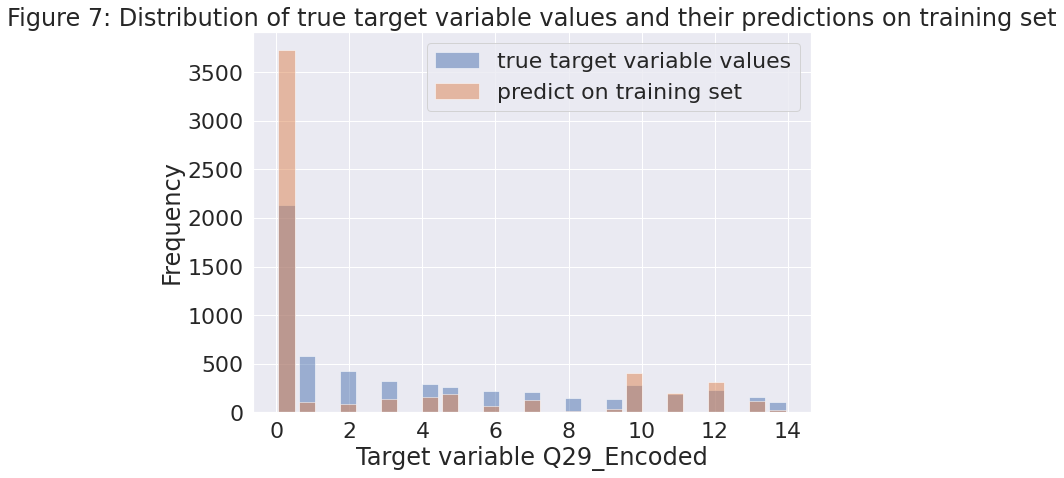

In [ ]:
#Plot the distribution of true target variable values and their predictions on both the training set and test set:
plt.figure(figsize = (10,7))
plt.hist(y_train_selected, bins = 25, rwidth = 0.8, label = 'true target variable values',alpha=0.5)
plt.hist(p_best_train, bins = 25, rwidth = 0.8, label = 'predict on training set',alpha=0.5)
plt.xlabel('Target variable Q29_Encoded')
plt.ylabel('Frequency')
plt.title('Figure 7: Distribution of true target variable values and their predictions on training set')
plt.legend()
plt.show()

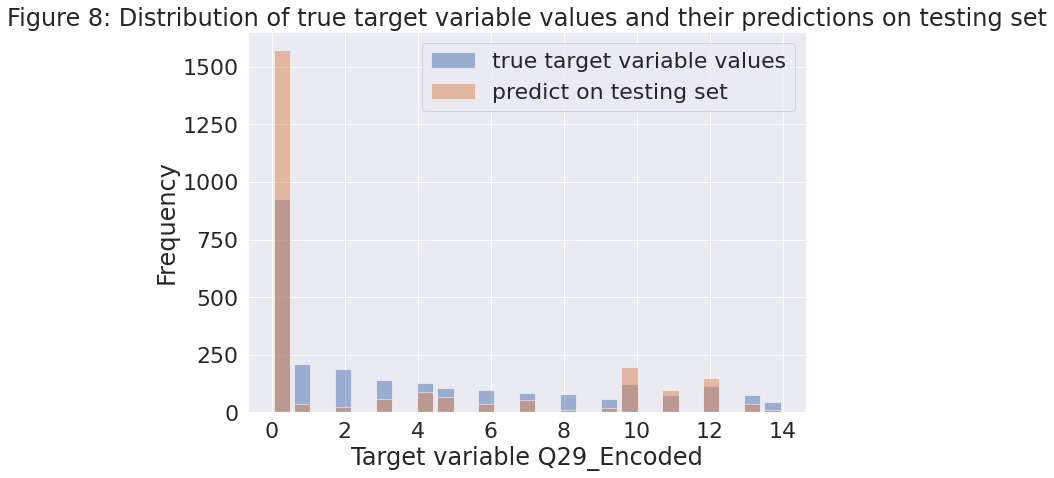

In [ ]:
plt.figure(figsize = (10,7))
plt.hist(y_test_selected, bins = 25, rwidth = 0.8, label = 'true target variable values',alpha=0.5)
plt.hist(p_best_test, bins = 25, rwidth = 0.8, label = 'predict on testing set',alpha=0.5)
plt.xlabel('Target variable Q29_Encoded')
plt.ylabel('Frequency')
plt.title('Figure 8: Distribution of true target variable values and their predictions on testing set')
plt.legend()
plt.show()